# 🏗️ 베이스라인 모델 구축: 5클래스 대화 분류

---

## 프로젝트 개요

| 항목 | 내용 |
|---|---|
| **과제** | 대화의 성격을 5개 클래스 중 하나로 분류 |
| **클래스** | `협박 대화`, `갈취 대화`, `직장 내 괴롭힘 대화`, `기타 괴롭힘 대화`, `일반 대화` |
| **평가 지표** | Macro F1 Score |
| **모델** | KLUE-RoBERTa-base (Fine-tuning) |
| **데이터** | `baseline.csv` — 위협 4클래스(증강) + 일반 대화(합성) |

### 참조 문서
- `docs/DLThon.md`: 대회 규칙 및 평가 항목
- `docs/strategy.md`: EDA 기반 데이터 전략 보고서
- `reports/eda_results.txt`: EDA 분석 수치
- `model_plan.md`: 모델 구현 계획서

---

## 1. 환경 설정 및 라이브러리 임포트

학습에 필요한 모든 라이브러리를 로드합니다.

| 라이브러리 | 용도 |
|---|---|
| `transformers` | KLUE-RoBERTa 모델 및 토크나이저 |
| `torch` | 모델 정의, 학습, 추론 |
| `sklearn` | 데이터 분할, F1 Score 계산, 혼동 행렬 |
| `pandas`, `numpy` | 데이터 처리 |
| `matplotlib`, `seaborn` | 시각화 |

In [1]:
# ============================================================
# Cell 1: 환경 설정 및 라이브러리 임포트
# ============================================================

# --- 기본 라이브러리 ---
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- HuggingFace Transformers ---
from transformers import AutoTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup

# --- 평가 ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --- 시각화 ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 한글 폰트 설정 (Windows 기준) ---
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 재현성 보장을 위한 시드 고정 ---
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# --- GPU 확인 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
if device.type == 'cuda':
    print(f'GPU 이름: {torch.cuda.get_device_name(0)}')
    print(f'GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

사용 디바이스: cuda
GPU 이름: NVIDIA GeForce RTX 3050 Laptop GPU
GPU 메모리: 4.3 GB


---

## 2. 데이터 로드 및 전처리

### 2-1. 데이터 로드

`baseline.csv`는 팀원이 다음 작업을 완료한 최종 학습 데이터입니다:
- **위협 4클래스**: 원본 데이터 + 증강(동의어 교체, 역번역 등)
- **일반 대화**: LLM 기반 합성 데이터 (~1,000건)
- **중복 제거**: 완전 중복(104건) + 준-중복(117건) 제거 완료

### 2-2. 텍스트 전처리 전략

| 처리 항목 | 결정 | 근거 (실전 데이터 통일 전략) |
|---|---|---|
| **줄바꿈 (`\n`)** | **공백(` `)으로 치환** | 실전(`test.csv`)에 개행이 없으므로, 구조적 편향을 막기 위해 모든 클래스를 단일 라인으로 평탄화 |
| `!`, `?` | 유지 | 문장 종결 및 감정 상태를 나타내는 중요한 힌트이므로 보존 |
| 이모티콘 | 별도 처리 불필요 | 학습 데이터 전체에서 0건 |
| 조사 (`을`, `를`) | 유지 | BERT 계열 모델이 문법 정보를 활용하도록 방치 |


In [ ]:
# ============================================================
# Cell 2: 데이터 로드 및 전처리
# ============================================================

# --- 2-1. 데이터 로드 ---
# train_final.csv: 증강/합성이 완료된 최종 학습 데이터
# val_final.csv: 격리된 최종 검증 데이터
train_df = pd.read_csv('../data/final_train_aug.csv')
val_df = pd.read_csv('../data/final_val.csv')

print(f'Train 데이터 크기: {train_df.shape}')
print(f'Val   데이터 크기: {val_df.shape}')
print(f'\n=== Train 클래스 분포 ===')
print(train_df['class'].value_counts())
print(f'\n=== Val 클래스 분포 ===')
print(val_df['class'].value_counts())


Train 데이터 크기: (3948, 3)
Val   데이터 크기: (987, 3)

=== Train 클래스 분포 ===
class
일반 대화          880
기타 괴롭힘 대화      802
갈취 대화          777
직장 내 괴롭힘 대화    775
협박 대화          714
Name: count, dtype: int64

=== Val 클래스 분포 ===
class
일반 대화          220
기타 괴롭힘 대화      200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178
Name: count, dtype: int64


In [ ]:
# ============================================================
# Cell 3: 레이블 인코딩 + 텍스트 전처리
# ============================================================

# 레이블 매핑 정의
label2id = {
    '갈취 대화': 0,
    '기타 괴롭힘 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '협박 대화': 3,
    '일반 대화': 4,
}
id2label = {v: k for k, v in label2id.items()}

# 레이블 컬럼 생성 (Train & Val)
train_df['label'] = train_df['class'].map(label2id)
val_df['label'] = val_df['class'].map(label2id)

print('레이블 매핑 완료 (Train & Val)')
print(f'클래스 수: {len(label2id)}개')


레이블 매핑 완료 (Train & Val)
클래스 수: 5개


In [ ]:
# ============================================================
# Cell 4: 텍스트 전처리 함수
# ============================================================

def preprocess(text):
    """
    대화 텍스트를 모델 입력에 적합한 형태로 변환합니다 (실전 데이터 정합성 버전).
    
    기존의 [SEP] 치환 전략 대신, 실전(test.csv)과 동일하게 
    모든 발화를 공백으로 연결하여 단일 문맥으로 처리합니다.
    """
    if not isinstance(text, str):
        return ""
        
    # 1. 혹시 남아있을 수 있는 줄바꿈을 공백으로 치환
    text = text.replace('\n', ' ')
    
    # 2. 연속된 공백을 단일 공백으로 정리 (정규화)
    import re
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# 전처리 적용 (Train & Val)
train_df['text'] = train_df['conversation'].apply(preprocess)
val_df['text'] = val_df['conversation'].apply(preprocess)

print(f'전처리 완료: Train({len(train_df)}), Val({len(val_df)})')


# 전처리 결과 확인
print('=== 전처리 전 (원본) ===')
print(train_df['conversation'].iloc[0][:200])
print(f'\n=== 전처리 후 ===')
print(train_df['text'].iloc[0][:200])
print(f'\n전처리 완료: {len(train_df)}건')

전처리 완료: Train(3948), Val(987)
=== 전처리 전 (원본) ===
상추가 왜 이렇게 시들시들해 이거 말고 저기 안쪽에 있는 게 더 싱싱해 보인다 오 진짜네 너 눈 좋다 고마워 고기 싸 먹으려면 싱싱해야지 응 우리 이따 비빔면도 같이 해서 먹자 완전 환상의 조합이네 얼른 계산하러 가자

=== 전처리 후 ===
상추가 왜 이렇게 시들시들해 이거 말고 저기 안쪽에 있는 게 더 싱싱해 보인다 오 진짜네 너 눈 좋다 고마워 고기 싸 먹으려면 싱싱해야지 응 우리 이따 비빔면도 같이 해서 먹자 완전 환상의 조합이네 얼른 계산하러 가자

전처리 완료: 3948건


---

## 3. Train / Validation 분할

학습 안정성과 일반화 성능을 평가하기 위해 데이터를 **80:20** 비율로 분할합니다.

| 파라미터 | 설정 | 이유 |
|---|---|---|
| 분할 비율 | 80:20 | 데이터가 ~5,000건으로 적으므로 검증 셋이 최소 1,000건은 확보되어야 함 |
| 층화 추출 (Stratify) | `label` 기준 | 클래스 비율이 Train/Val에서 동일하게 유지되도록 |
| Random Seed | 42 | 재현성 보장 |

In [ ]:
# ============================================================
# Cell 5: Train/Validation 분할
# ============================================================


# 이미 물리적으로 분산된 파일을 직접 로드했으므로, 리스트로 속성 추출만 수행
train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()
val_texts = val_df['text'].tolist()
val_labels = val_df['label'].tolist()

print(f'데이터셋 준비 완료 | Train: {len(train_texts)}건, Val: {len(val_texts)}건')

# 클래스 비율 최종 확인
print(f'\n=== Train 클래스 분포 (%) ===')
print(train_df['class'].value_counts(normalize=True) * 100)


데이터셋 준비 완료 | Train: 3948건, Val: 987건

=== Train 클래스 분포 (%) ===
class
일반 대화          22.289767
기타 괴롭힘 대화      20.314083
갈취 대화          19.680851
직장 내 괴롭힘 대화    19.630193
협박 대화          18.085106
Name: proportion, dtype: float64


---

## 4. 토크나이저 및 Dataset 정의

### 4-1. 토크나이저: KLUE-RoBERTa

KLUE-RoBERTa의 전용 토크나이저(BPE 기반)를 사용합니다.  
한국어 텍스트를 서브워드 단위로 분절하여 OOV(미등록 단어) 문제를 최소화합니다.

### 4-2. MAX_LEN = 256 설정 근거

| EDA 수치 | 값 |
|---|---|
| 글자 수 중간값 | 203자 |
| 글자 수 75% | 270자 |
| 글자 수 최대 | 874자 |

- RoBERTa 토크나이저는 한국어 1글자당 약 1~2 토큰을 생성
- **256 토큰**이면 대부분의 대화(75%)를 완전히 커버
- 512 대비 **메모리 50% 절약** → 배치 사이즈 증가 가능

In [ ]:
# ============================================================
# Cell 6: 토크나이저 및 하이퍼파라미터 설정
# ============================================================

# --- 모델 이름 ---
# KLUE-RoBERTa-base: 한국어 특화 사전학습 모델
# - BERT 대비 Dynamic Masking + NSP 제거로 문맥 파악 능력 향상
# - 110M 파라미터로 Ablation Study 반복에 적합한 크기
MODEL_NAME = 'klue/roberta-base'

# --- 하이퍼파라미터 ---
MAX_LEN = 256       # 토큰 최대 길이 (기존 세팅 유지: 글자 중간값 203, 75%=270)
BATCH_SIZE = 16     # 배치 크기 (GPU 메모리 여유가 있다면 16이나 32 권장, 아웃오브메모리 나면 8로 내림)
LEARNING_RATE = 1e-4  # 백본 기준 Fine-tuning 표준 범위 
EPOCHS = 30          # 학습 에폭 (데이터 1.5만 건 → 3~5 에폭이면 완전히 수렴함. 30은 과적합 위험!)
WARMUP_RATIO = 0.1  # 학습 초기 10% 스텝은 워밍업 (사전학습 가중치 붕괴 방지)
WEIGHT_DECAY = 0.02 # L2 정규화 계수 (과적합 억제)
DROPOUT_RATE = 0.3  # 분류 헤드 드롭아웃 (구조 안정성 확보)


# --- 토크나이저 로드 ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'모델: {MODEL_NAME}')
print(f'MAX_LEN: {MAX_LEN}')
print(f'BATCH_SIZE: {BATCH_SIZE}')
print(f'LEARNING_RATE: {LEARNING_RATE}')
print(f'EPOCHS: {EPOCHS}')
print(f'DROPOUT_RATE: {DROPOUT_RATE}')
print(f'Vocab Size: {tokenizer.vocab_size}')

# --- 토크나이저 동작 확인 ---
sample_text = train_texts[0][:100]
tokens = tokenizer.tokenize(sample_text)
print(f'\n=== 토크나이저 동작 확인 ===')
print(f'원문 ({len(sample_text)}자): {sample_text}')
print(f'토큰 ({len(tokens)}개): {tokens[:20]}...')

모델: klue/roberta-base
MAX_LEN: 256
BATCH_SIZE: 16
LEARNING_RATE: 0.0001
EPOCHS: 30
DROPOUT_RATE: 0.3
Vocab Size: 32000

=== 토크나이저 동작 확인 ===
원문 (100자): 상추가 왜 이렇게 시들시들해 이거 말고 저기 안쪽에 있는 게 더 싱싱해 보인다 오 진짜네 너 눈 좋다 고마워 고기 싸 먹으려면 싱싱해야지 응 우리 이따 비빔면도 같이 해서 먹자 완
토큰 (48개): ['상추', '##가', '왜', '이렇게', '시들', '##시', '##들', '##해', '이거', '말', '##고', '저기', '안쪽', '##에', '있', '##는', '게', '더', '싱싱', '##해']...


In [ ]:
# ============================================================
# Cell 7: PyTorch Dataset 클래스 정의
# ============================================================

class ConversationDataset(Dataset):
    """
    대화 텍스트를 KLUE-RoBERTa 입력 형식으로 변환하는 Dataset 클래스.
    
    각 샘플은 다음으로 구성됩니다:
    - input_ids: 토큰 ID 시퀀스 (0~vocab_size)
    - attention_mask: 실제 토큰(1) vs 패딩(0) 구분
    - label: 정수 레이블 (0~4)
    """
    
    def __init__(self, texts, labels, tokenizer, max_len):
        """
        Args:
            texts (list[str]): 전처리된 텍스트 리스트
            labels (list[int]): 정수 레이블 리스트
            tokenizer: HuggingFace 토크나이저
            max_len (int): 최대 토큰 수
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        # 텍스트를 토큰화하여 모델 입력 형식으로 변환
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,      # 최대 길이 제한
            padding='max_length',         # 짧은 시퀀스는 패딩
            truncation=True,              # 긴 시퀀스는 잘라냄
            return_tensors='pt',          # PyTorch 텐서 반환
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),         # (MAX_LEN,)
            'attention_mask': encoding['attention_mask'].squeeze(0), # (MAX_LEN,)
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }


# --- Dataset 생성 ---
train_dataset = ConversationDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = ConversationDataset(val_texts, val_labels, tokenizer, MAX_LEN)

# --- DataLoader 생성 ---
# Train: shuffle=True (매 에폭마다 데이터 순서 섞기)
# Val: shuffle=False (평가 시에는 순서 유지)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train Dataset: {len(train_dataset)}건 → {len(train_loader)} 배치')
print(f'Val   Dataset: {len(val_dataset)}건 → {len(val_loader)} 배치')

# --- 배치 형태 확인 ---
sample_batch = next(iter(train_loader))
print(f'\n=== 배치 형태 확인 ===')
print(f"input_ids shape:      {sample_batch['input_ids'].shape}")       # (BATCH, MAX_LEN)
print(f"attention_mask shape: {sample_batch['attention_mask'].shape}")  # (BATCH, MAX_LEN)
print(f"label shape:          {sample_batch['label'].shape}")           # (BATCH,)

Train Dataset: 3948건 → 247 배치
Val   Dataset: 987건 → 62 배치

=== 배치 형태 확인 ===
input_ids shape:      torch.Size([16, 256])
attention_mask shape: torch.Size([16, 256])
label shape:          torch.Size([16])


---

## 5. 모델 정의

### 아키텍처 구조

```
[입력 텍스트]
    │
    ▼
KLUE-RoBERTa-base (768 hidden dim)
    │
    ▼
[CLS] 토큰 출력 (768차원) ← 대화 전체의 의미를 응축한 벡터
    │
    ▼
Dropout (p=0.3) ← 전략적 증강 데이터(~15,000건)에 대한 과적합 방지
    │
    ▼
Linear (768 → 5) ← 5클래스 분류
    │
    ▼
[Logits] → CrossEntropyLoss

```

[설계 결정 근거]
| 결정 | 선택 | 근거 |
|---|---|---|
| 풀링 방식 | [CLS] 토큰 | 문장 분류 태스크 표준. 문맥 전체 의미를 파악하는 최고 안정적 방식 |
| Dropout | 0.3 | 증강을 통해 데이터가 15,000건으로 늘었으나, 패턴 과적합을 막기 위해 0.3 유지 |
| 분류 헤드 | 단일 Linear | 베이스라인의 안정성을 위해 단순 구조 채택. 추후 MLP 고도화 예정 |

In [ ]:
# ============================================================
# Cell 8: 분류 모델 정의 (Weighted Pooling + Residual Head + Partial Unfreeze + Post-LN)
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

# 잔차 연결 블록 (깊은 층에서 핵심 키워드 정보 소실 방지)
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout_rate=0.3):
        super().__init__()
        self.fc = nn.Linear(dim, dim)
        self.ln = nn.LayerNorm(dim)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        residual = x # 원본 정보 저장
        out = self.fc(x)
        out = self.ln(out)
        out = self.gelu(out)
        out = self.dropout(out)
        return out + residual # 우회 도로(잔차) 더하기

class ConversationClassifier(nn.Module): 
    def __init__(self, model_name, num_classes=5, dropout_rate=0.3, freeze_backbone=False): 
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size # 768
        
        # [핵심 1] Partial Unfreeze: 전체를 얼리되, 마지막 2개 층만 열어 미세 뉘앙스 학습
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            for param in self.backbone.encoder.layer[-2:].parameters():
                param.requires_grad = True
            print("❄️ 백본 가중치 고정됨 (단, 마지막 2개 층은 Partial Unfreeze 적용)")
            
        # [핵심 2] Weighted Layer Pooling 가중치 (임베딩 1 + 히든 12 = 총 13층)
        self.layer_weights = nn.Parameter(torch.ones(13))
        
        # 헤드 입력 차원 (Mean 768 + Max 768 = 1536)
        input_dim = hidden_size * 2  
        
        # [핵심 3] 깊은 헤드 구조 (풀링 직후 정규화를 없애고, Linear 통과 후 정규화)
        self.fc1 = nn.Linear(input_dim, 512)
        self.layer_norm1 = nn.LayerNorm(512) # 🌟 1536 생날것을 섞은 후 여기서 정규화!
        self.activation1 = nn.GELU()
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # [핵심 4] 잔차 연결 블록 삽입
        self.res_block = ResidualBlock(512, dropout_rate)
        
        # 두 번째 은닉층
        self.fc2 = nn.Linear(512, 256)
        self.layer_norm2 = nn.LayerNorm(256)
        self.activation2 = nn.GELU()
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # 최종 로짓 출력층
        self.fc3 = nn.Linear(256, num_classes)
    
    def pool(self, all_hidden_states, attention_mask):
        # 13개 층을 학습된 가중치 비율로 섞음
        weights = F.softmax(self.layer_weights, dim=0)
        weighted_hidden = sum(w * h for w, h in zip(weights, all_hidden_states))
        
        mask_expanded = attention_mask.unsqueeze(-1).float()
        
        # Mean Pooling (문맥)
        sum_embeddings = torch.sum(weighted_hidden * mask_expanded, dim=1)
        sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
        mean_pooled = sum_embeddings / sum_mask
        
        # Max Pooling (핵심 키워드 에너지)
        masked_hidden = weighted_hidden.masked_fill(attention_mask.unsqueeze(-1) == 0, -1e9)
        max_pooled = torch.max(masked_hidden, dim=1)[0]
        
        # 🌟 정규화 없이 순수한 에너지를 그대로 이어붙임
        return torch.cat([mean_pooled, max_pooled], dim=1)
    
    def forward(self, input_ids, attention_mask):
        # output_hidden_states=True로 전 층의 아웃풋을 받음
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
        
        # 커스텀 Pooler 통과 (1536차원 순수 벡터 생성)
        pooled_output = self.pool(outputs.hidden_states, attention_mask)
        
        # 1층: Linear 믹싱 후 정규화
        hidden = self.fc1(pooled_output)
        hidden = self.layer_norm1(hidden) # 🌟 사용자의 통찰이 담긴 진짜 꿀자리
        hidden = self.activation1(hidden)
        hidden = self.dropout1(hidden)
        
        # 2층: 잔차 블록 통과
        hidden = self.res_block(hidden)
        
        # 3층: 압축 및 정규화
        hidden = self.fc2(hidden)
        hidden = self.layer_norm2(hidden)
        hidden = self.activation2(hidden)
        hidden = self.dropout2(hidden)
        
        # 출력
        logits = self.fc3(hidden)
        return logits

# --- 모델 인스턴스 생성 ---
model = ConversationClassifier(
    model_name=MODEL_NAME,
    num_classes=len(label2id),
    dropout_rate=DROPOUT_RATE,
    freeze_backbone=True
).to(device)

# --- 파라미터 수 확인 ---
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\n{"="*50}')
print(f'🤖 모델 인스턴스 생성 완료 (최종 병기 아키텍처 V2)')
print(f'전체 파라미터: {total_params:,}개')
print(f'학습 가능 파라미터: {trainable_params:,}개 ({trainable_params/total_params*100:.2f}%)')
print(f'{"="*50}\n')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


❄️ 백본 가중치 고정됨 (단, 마지막 2개 층은 Partial Unfreeze 적용)

🤖 모델 인스턴스 생성 완료 (최종 병기 아키텍처 V2)
전체 파라미터: 111,802,898개
학습 가능 파라미터: 15,360,530개 (13.74%)



In [ ]:
# ============================================================
# Cell 9: 옵티마이저, 스케줄러, 손실 함수 설정 (V2 대응)
# ============================================================
import torch
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

# --- 1. 파라미터 분리 및 학습 대상 선별 ---
head_params = []
backbone_params = []

for name, param in model.named_parameters():
    # ❄️ 가중치가 고정된(requires_grad=False) 파라미터는 옵티마이저에서 제외
    if not param.requires_grad:
        continue 
    
    # [중요] 이름에 'backbone'이 들어가지 않은 모든 부품은 '헤드 및 커스텀 레이어'로 분류
    # 여기에는 fc1~3, res_block, layer_weights, layer_norm1~2 등이 모두 포함됩니다.
    if 'backbone' not in name:
        head_params.append(param)
    else:
        #requires_grad가 True이면서 backbone인 것 (즉, Partial Unfreeze된 10, 11번 레이어)
        backbone_params.append(param)

# 🌟 차등 학습률(Discriminative LR) 설정
# 백본은 이미 완성된 지식이므로 아주 천천히(1/10) 학습하고, 헤드는 새롭게 배우므로 원래 속도로 학습
BACKBONE_LEARNING_RATE = LEARNING_RATE / 10  
HEAD_LEARNING_RATE = LEARNING_RATE           

optimizer_grouped_parameters = [
    {'params': backbone_params, 'lr': BACKBONE_LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
    {'params': head_params, 'lr': HEAD_LEARNING_RATE, 'weight_decay': WEIGHT_DECAY}
]

# --- 2. 옵티마이저: AdamW ---
optimizer = torch.optim.AdamW(optimizer_grouped_parameters)

# --- 3. 스케줄러: Linear Warmup + Decay ---
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# --- 4. 손실 함수: Label Smoothing 적용 (과적합 방지 및 일반화 성능 향상) ---
# 0.1 정도의 스무딩을 주면 모델이 너무 오만하게 확신하지 않아 6에폭 뻥크를 막는 데 효과적입니다.
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# --- 5. 설정 검증 출력 ---
print(f'\n{"="*60}')
print(f'🤖 모델 구조 및 학습 파라미터 정보 (최종 병기 V2)')
print(f'{"="*60}')
print(f'Total Parameters   : {total_params:,} 개')
print(f'Trainable Params   : {trainable_params:,} 개 ({trainable_params/total_params*100:.2f}%)')
print(f'-'*60)
print(f'⚙️ 최적화 및 스케줄러 설정')
print(f'-'*60)
print(f'Total steps  : {total_steps:,} 스텝')
print(f'Warmup steps : {warmup_steps:,} 스텝')
print(f'Optimizer    : AdamW (Discriminative LR - 전략적 차등 학습)')
print(f'  - Backbone LR : {BACKBONE_LEARNING_RATE} (마지막 2개 층 미세 조정)')
print(f'  - Head LR     : {HEAD_LEARNING_RATE} (커스텀 헤드 집중 학습)')
print(f'Scheduler    : Linear Warmup + Decay')
print(f'Loss         : CrossEntropyLoss (Label Smoothing 0.1 적용 🌟)')
print(f'{"="*60}\n')



🤖 모델 구조 및 학습 파라미터 정보 (최종 병기 V2)
Total Parameters   : 111,802,898 개
Trainable Params   : 15,360,530 개 (13.74%)
------------------------------------------------------------
⚙️ 최적화 및 스케줄러 설정
------------------------------------------------------------
Total steps  : 7,410 스텝
Warmup steps : 741 스텝
Optimizer    : AdamW (Discriminative LR - 전략적 차등 학습)
  - Backbone LR : 1e-05 (마지막 2개 층 미세 조정)
  - Head LR     : 0.0001 (커스텀 헤드 집중 학습)
Scheduler    : Linear Warmup + Decay
Loss         : CrossEntropyLoss (Label Smoothing 0.1 적용 🌟)



---

## 6. 학습 설정

### 옵티마이저 & 스케줄러

| 구성 요소 | 선택 | 근거 |
|---|---|---|
| **옵티마이저** | AdamW | BERT fine-tuning 표준. Weight Decay를 적용하여 L2 정규화 |
| **스케줄러** | Linear Warmup + Decay | 초기 10% 구간은 LR을 서서히 올려 학습 안정화 |
| **손실 함수** | CrossEntropyLoss | 다중 클래스 분류 표준 |
| **Gradient Clipping** | `max_norm=1.0` | 그래디언트 폭발 방지 |

---

## 7. 학습 실행

### 학습 루프 구조

각 에폭마다 다음을 수행합니다:

1. **학습(Train)**: 전체 Train 데이터를 순회하며 모델 가중치 업데이트
2. **검증(Validation)**: 전체 Val 데이터에 대해 손실과 F1 Score 측정
3. **Best Model 저장**: Val F1이 갱신되면 모델 가중치를 저장

### 핵심 기법

| 기법 | 설명 |
|---|---|
| **Gradient Clipping** | 그래디언트 크기를 `max_norm=1.0`으로 제한하여 폭발 방지 |
| **Best Model 저장** | Val F1 기준으로 최고 성능 모델만 보존 (Early Stopping 대용) |

In [ ]:
# ============================================================
# Cell 10: 학습 & 검증 함수 정의 (tqdm 게이지 추가 버전)
# ============================================================
from tqdm.auto import tqdm

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    """
    1 에폭 학습을 수행합니다.
    
    Returns:
        avg_loss (float): 평균 손실
        f1 (float): Macro F1 Score
    """
    model.train()  # 학습 모드 (Dropout 활성화)
    total_loss = 0
    all_preds, all_trues = [], []
    
    # --- tqdm 진행바 설정 ---
    pbar = tqdm(loader, desc="  Training", leave=False)
    
    for batch in pbar:
        # --- 데이터를 GPU로 전송 ---
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # --- Forward pass ---
        optimizer.zero_grad()  # 이전 그래디언트 초기화
        logits = model(input_ids, attention_mask)  # (batch, 5)
        loss = criterion(logits, labels)
        
        # --- Backward pass ---
        loss.backward()  # 그래디언트 계산
        
        # Gradient Clipping: 그래디언트가 1.0을 초과하면 스케일링
        # → 학습 안정성 확보 (RoBERTa fine-tuning 시 권장)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()   # 가중치 업데이트
        scheduler.step()   # 러닝 레이트 스케줄 업데이트
        
        # --- 메트릭 수집 ---
        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())  # 예측 클래스
        all_trues.extend(labels.cpu().numpy())                 # 정답 클래스
        
        # --- 진행바 상태 업데이트 ---
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_trues, all_preds, average='macro')  # Macro F1
    return avg_loss, f1


def evaluate(model, loader, criterion, device):
    """
    검증/테스트를 수행합니다.
    
    Returns:
        avg_loss (float): 평균 손실
        f1 (float): Macro F1 Score
        all_preds (list): 전체 예측값
        all_trues (list): 전체 정답값
    """
    model.eval()  # 평가 모드 (Dropout 비활성화)
    total_loss = 0
    all_preds, all_trues = [], []
    
    # --- tqdm 진행바 설정 ---
    pbar = tqdm(loader, desc="  Evaluating", leave=False)
    
    with torch.no_grad():  # 그래디언트 계산 비활성화 (메모리/속도 절약)
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            all_trues.extend(labels.cpu().numpy())
            
            # --- 진행바 상태 업데이트 ---
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_trues, all_preds, average='macro')
    return avg_loss, f1, all_preds, all_trues


print('학습/검증 함수 정의 완료 (tqdm 적용)')


학습/검증 함수 정의 완료 (tqdm 적용)


In [ ]:
# ============================================================
# Cell 11: 메인 학습 루프 실행 (진행바 및 시간 측정 추가)
# ============================================================
from tqdm.auto import tqdm
import time
import os

best_f1 = 0         # 최고 Val F1 기록
history = []         # 에폭별 학습 기록

print('=' * 70)
print(f'학습 시작 | 모델: {MODEL_NAME} | 디바이스: {device}')
print(f'Train: {len(train_dataset)}건 | Val: {len(val_dataset)}건 | Epochs: {EPOCHS}')
print('=' * 70)

for epoch in range(EPOCHS):
    epoch_start_time = time.time()  # 에폭 시작 시간 기록
    
    # --- 학습 ---
    # train_epoch 함수 내부에서도 tqdm을 쓸 수 있지만, 
    # 루프 밖에서 에폭 상황을 먼저 출력합니다.
    print(f'\n[Epoch {epoch+1}/{EPOCHS}]')
    
    train_loss, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device
    )
    
    # --- 검증 ---
    val_loss, val_f1, val_preds, val_trues = evaluate(
        model, val_loader, criterion, device
    )
    
    epoch_end_time = time.time()   # 에폭 종료 시간 기록
    epoch_duration = epoch_end_time - epoch_start_time
    
    # --- 에폭별 기록 저장 ---
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_f1': train_f1,
        'val_loss': val_loss,
        'val_f1': val_f1,
        'lr': scheduler.get_last_lr()[0],
        'duration': epoch_duration
    })
    
    # --- 에폭 결과 출력 ---
    print(f'  >> Time: {epoch_duration:.2f}s')
    print(f'  >> Train | Loss: {train_loss:.4f} | F1: {train_f1:.4f}')
    print(f'  >> Val   | Loss: {val_loss:.4f} | F1: {val_f1:.4f}')
    print(f'  >> LR: {scheduler.get_last_lr()[0]:.2e}')
    
      # --------------------------------------------------------
    # --- 매 에폭 모델 독립 저장 (Epoch Checkpointing) ---
    # --------------------------------------------------------
    # 예: epoch 1이면 'best_model_v4_ep1.pt', epoch 2면 'best_model_v4_ep2.pt'
   
       # 경로 설정
    save_path = f'models/no_aug_ep{epoch + 1}.pt'
    
    # 폴더가 없으면 생성 (들여쓰기 주의!)
    if not os.path.exists('models'):
        os.makedirs('models')
        print("✅ 'models' 폴더를 생성했습니다.")
        
    # 모델 저장 및 출력
    torch.save(model.state_dict(), save_path)
    print(f'  💾 Epoch {epoch} model saved at: {save_path}')

    # --- Best Model 갱신 기록 (선택 사항) ---
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch
        print(f'  ⭐ New Best F1 Score 갱신: {best_f1:.4f} (Epoch {epoch + 1})')

print('\n' + '=' * 70)
print(f'학습 완료 | Best Val F1: {best_f1:.4f} (from Epoch {best_epoch})')
print('=' * 70)



학습 시작 | 모델: klue/roberta-base | 디바이스: cuda
Train: 3948건 | Val: 987건 | Epochs: 30

[Epoch 1/30]


  Training:   0%|          | 0/247 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/62 [00:00<?, ?it/s]

  >> Time: 173.94s
  >> Train | Loss: 1.6003 | F1: 0.2599
  >> Val   | Loss: 1.3444 | F1: 0.4486
  >> LR: 3.33e-06
  💾 Epoch 0 model saved at: models/no_aug_ep1.pt
  ⭐ New Best F1 Score 갱신: 0.4486 (Epoch 1)

[Epoch 2/30]


  Training:   0%|          | 0/247 [00:00<?, ?it/s]

...

  Training:   0%|          | 0/247 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/62 [00:00<?, ?it/s]

  >> Time: 281.93s
  >> Train | Loss: 0.5124 | F1: 0.9463
  >> Val   | Loss: 0.5838 | F1: 0.9177
  >> LR: 7.41e-06
  💾 Epoch 9 model saved at: models/no_aug_ep10.pt

[Epoch 11/30]


  Training:   0%|          | 0/247 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import os
import torch

# 1. 일단 폴더부터 강제로 만듭니다 (에러 원인 차단)
if not os.path.exists('models'):
    os.makedirs('models')

# 2. 메모리에 살아있는 모델을 강제로 저장합니다.
torch.save(model.state_dict(), 'models/recovered_best_model.pt')

print("✅ 휴! 모델 복구에 성공했습니다. 'models/recovered_best_model.pt' 파일을 확인하세요!")


✅ 휴! 모델 복구에 성공했습니다. 'models/recovered_best_model.pt' 파일을 확인하세요!


---

## 8. 평가 및 분석

최적 모델(Best Val F1)을 로드하여 상세한 성능 분석을 수행합니다.

### 분석 항목

| 분석 | 목적 |
|---|---|
| **Classification Report** | 클래스별 Precision, Recall, F1 확인 |
| **혼동 행렬** | 어떤 클래스 쌍이 가장 많이 혼동되는지 시각화 |
| **학습 곡선** | 과적합 여부 (Train-Val Loss 격차) 확인 |

### 혼동 행렬 분석 포인트 (strategy.md 기반)
- `협박 ↔ 기타 괴롭힘`: 코사인 유사도 **0.87**로 가장 높음 → 혼동 예상
- `협박 ↔ 갈취`: 코사인 유사도 **0.83** → 두 번째 혼동 위험
- `일반 대화`: 위협 클래스로 오분류되는 비율 → 합성 데이터 품질 지표

In [ ]:
# ============================================================
# Cell 12: Best Model 로드 및 상세 평가
# ============================================================

# --- 최적 모델 로드 후 최종 검증 수행 ---
model.load_state_dict(torch.load('best_model_v3.pt'))
final_loss, final_f1, final_preds, final_trues = evaluate(model, val_loader, criterion, device)

# --- Classification Report ---
class_names = [id2label[i] for i in range(len(id2label))]
print('\n' + '=' * 60)
print('Classification Report (Best Model on Validation Set)')
print('=' * 60)
print(classification_report(
    final_trues, final_preds,
    target_names=class_names,
    digits=4,
))
print(f'Overall Macro F1: {final_f1:.4f}')


RuntimeError: Error(s) in loading state_dict for ConversationClassifier:
	Missing key(s) in state_dict: "layer_weights", "layer_norm1.weight", "layer_norm1.bias", "res_block.fc.weight", "res_block.fc.bias", "res_block.ln.weight", "res_block.ln.bias", "layer_norm2.weight", "layer_norm2.bias", "fc3.weight", "fc3.bias". 
	Unexpected key(s) in state_dict: "layer_norm.weight", "layer_norm.bias". 
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 768]) from checkpoint, the shape in current model is torch.Size([512, 1536]).
	size mismatch for fc1.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for fc2.weight: copying a param with shape torch.Size([5, 256]) from checkpoint, the shape in current model is torch.Size([256, 512]).
	size mismatch for fc2.bias: copying a param with shape torch.Size([5]) from checkpoint, the shape in current model is torch.Size([256]).

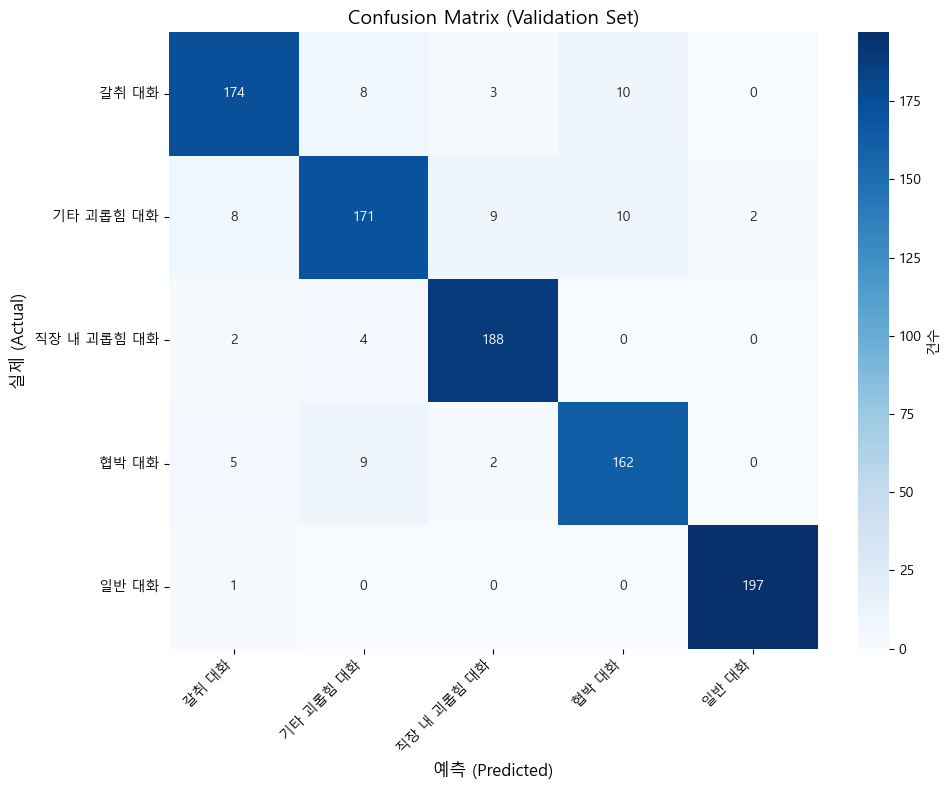


=== 오분류 분석 (상위 5건) ===
  1위: [갈취 대화] → [협박 대화]으로 10건 오분류
  2위: [기타 괴롭힘 대화] → [협박 대화]으로 10건 오분류
  3위: [기타 괴롭힘 대화] → [직장 내 괴롭힘 대화]으로 9건 오분류
  4위: [협박 대화] → [기타 괴롭힘 대화]으로 9건 오분류
  5위: [갈취 대화] → [기타 괴롭힘 대화]으로 8건 오분류


In [ ]:
# ============================================================
# Cell 13: 혼동 행렬 시각화
# ============================================================

# 혼동 행렬 계산
cm = confusion_matrix(final_trues, final_preds)

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    cbar_kws={'label': '건수'},
)
plt.title('Confusion Matrix (Validation Set)', fontsize=14)
plt.ylabel('실제 (Actual)', fontsize=12)
plt.xlabel('예측 (Predicted)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 혼동 분석 ---
# 대각선 제외, 오분류가 가장 많은 쌍을 식별
print('\n=== 오분류 분석 (상위 5건) ===')
confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((
                class_names[i],  # 실제
                class_names[j],  # 예측
                cm[i][j],        # 건수
            ))
confusion_pairs.sort(key=lambda x: -x[2])
for rank, (actual, pred, count) in enumerate(confusion_pairs[:5], 1):
    print(f'  {rank}위: [{actual}] → [{pred}]으로 {count}건 오분류')

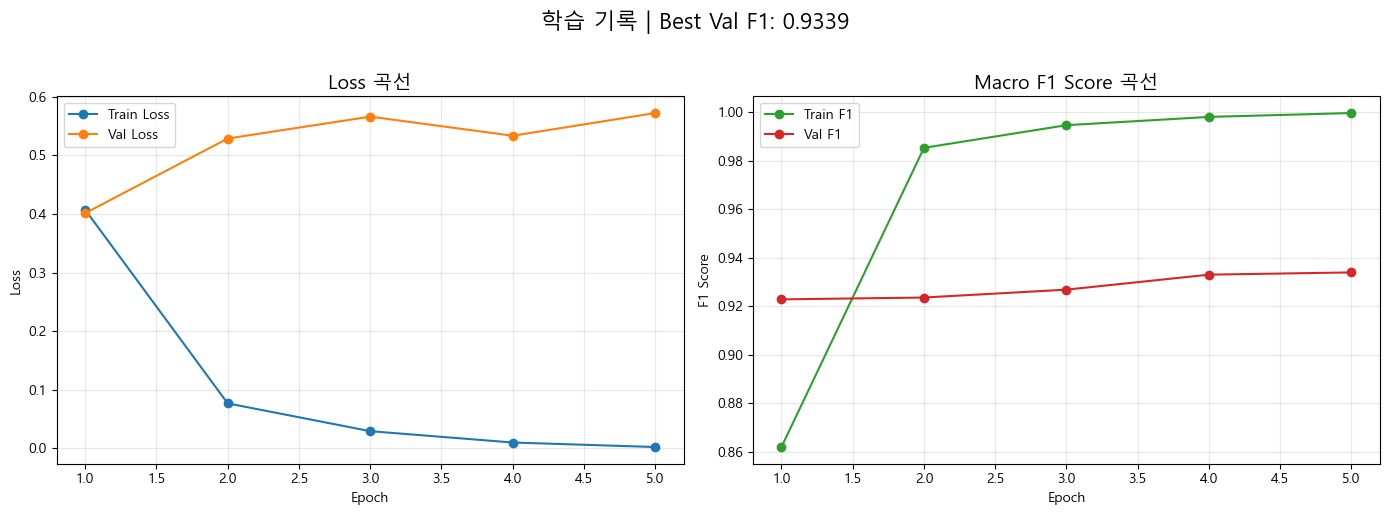


=== 에폭별 학습 기록 ===
 epoch  train_loss  train_f1  val_loss  val_f1     lr  duration
     1      0.4071    0.8620    0.4012  0.9228 0.0000 1483.8817
     2      0.0769    0.9853    0.5285  0.9236 0.0000 1566.5615
     3      0.0295    0.9946    0.5659  0.9269 0.0000 1566.6073
     4      0.0101    0.9980    0.5333  0.9330 0.0000 1566.5715
     5      0.0024    0.9996    0.5720  0.9339 0.0000 1566.5642


In [ ]:
# ============================================================
# Cell 14: 학습 곡선 시각화
# ============================================================

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss 곡선 ---
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], 'o-', label='Val Loss', color='#ff7f0e')
axes[0].set_title('Loss 곡선', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- F1 Score 곡선 ---
axes[1].plot(hist_df['epoch'], hist_df['train_f1'], 'o-', label='Train F1', color='#2ca02c')
axes[1].plot(hist_df['epoch'], hist_df['val_f1'], 'o-', label='Val F1', color='#d62728')
axes[1].set_title('Macro F1 Score 곡선', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'학습 기록 | Best Val F1: {best_f1:.4f}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- 학습 기록 테이블 출력 ---
print('\n=== 에폭별 학습 기록 ===')
print(hist_df.to_string(index=False, float_format='{:.4f}'.format))

---

## 9. 추론 및 제출 파일 생성

학습 완료된 최적 모델로 `test.csv`를 추론하여 `submission.csv`를 생성합니다.

### 추론 파이프라인

```
test.csv → 전처리(preprocess) → 토큰화 → 모델 추론(eval mode) → argmax → 레이블 디코딩 → submission.csv
```

In [ ]:
# ============================================================
# Cell 15: 추론 및 submission.csv 생성
# ============================================================

# --- 테스트 데이터 로드 ---
test_df = pd.read_csv('../data/test.csv')
print(f'테스트 데이터: {len(test_df)}건')
print(f'컬럼: {test_df.columns.tolist()}')

# --- 전처리 적용 (학습 시와 동일한 전처리 + 예외 처리) ---
# 1. test.csv 특유의 제멋대로인 큰따옴표(") 강제 제거 및 다중 공백 정리
import re
test_df['text'] = test_df['conversation'].apply(lambda x: re.sub(r'\s+', ' ', str(x).replace('"', '')).strip())

# 2. 기존 학습 시 사용했던 전처리 함수(특수문자 제거 등) 이중 적용
test_df['text'] = test_df['text'].apply(preprocess)


# --- Dataset & DataLoader 생성 ---
# 테스트에는 레이블이 없으므로 더미 레이블(0)을 사용
test_dataset = ConversationDataset(
    texts=test_df['text'].tolist(),
    labels=[0] * len(test_df),  # 더미 레이블 (사용하지 않음)
    tokenizer=tokenizer,
    max_len=MAX_LEN,
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 최적 모델 로드 ---
model.load_state_dict(torch.load('models/no_aug_ep.pt'))
model.eval()

# --- 추론 실행 ---
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        logits = model(input_ids, attention_mask)
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)

# --- 레이블 디코딩 ---
# --- 수정 코드 (모든 값을 문자열로 강제 변환) ---
test_df['class'] = [str(id2label[p]) for p in all_preds] 


# --- submission.csv 생성 ---
submission = test_df[['idx', 'class']]
submission.to_csv('submission.csv', index=False)

print('\n=== submission.csv 생성 완료 ===')
print(f'파일 크기: {len(submission)}건')
print(f'\n=== 예측 클래스 분포 ===')
print(submission['class'].value_counts())
print(f'\n=== 상위 5건 미리보기 ===')
print(submission.head())

테스트 데이터: 500건
컬럼: ['idx', 'conversation']


RuntimeError: Error(s) in loading state_dict for ConversationClassifier:
	Missing key(s) in state_dict: "layer_weights", "layer_norm1.weight", "layer_norm1.bias", "res_block.fc.weight", "res_block.fc.bias", "res_block.ln.weight", "res_block.ln.bias", "layer_norm2.weight", "layer_norm2.bias", "fc3.weight", "fc3.bias". 
	Unexpected key(s) in state_dict: "layer_norm.weight", "layer_norm.bias". 
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 768]) from checkpoint, the shape in current model is torch.Size([512, 1536]).
	size mismatch for fc1.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for fc2.weight: copying a param with shape torch.Size([5, 256]) from checkpoint, the shape in current model is torch.Size([256, 512]).
	size mismatch for fc2.bias: copying a param with shape torch.Size([5]) from checkpoint, the shape in current model is torch.Size([256]).

In [ ]:
print(submission['class'].apply(type).value_counts())


class
<class 'str'>    500
Name: count, dtype: int64


In [ ]:
# '기타 괴롭힘 대화'로 예측된 샘플 30건 집중 분석
target_class = '일반 대화'
target_samples = test_df[test_df['class'] == target_class]

print(f"{'='*60}")
print(f"🔍 [{target_class}] 예측 샘플 집중 분석 (총 {len(target_samples)}건 중 30건)")
print(f"{'='*60}")

# 상위 30개 추출 (데이터가 30개보다 적을 경우 전체 출력)
samples_to_show = target_samples.head(162)

for i, (idx, row) in enumerate(samples_to_show.iterrows()):
    print(f"[{i+1}] (Test ID: {row['idx']})")
    print(f"내용: {row['conversation']}")
    print("-" * 50)

if len(target_samples) == 0:
    print("해당 클래스로 예측된 샘플이 없습니다.")


🔍 [일반 대화] 예측 샘플 집중 분석 (총 84건 중 30건)
[1] (Test ID: t_003)
내용: 이거 들어바 와 이 노래 진짜 좋다 그치 요즘 이 것만 들어 진짜 너무 좋다 내가 요즘 듣는 것도 들어봐 음 난 좀 별론데 좋을 줄 알았는데 아쉽네 내 취향은 아닌 듯 배고프다 밥이나 먹으러 가자 그래
--------------------------------------------------
[2] (Test ID: t_008)
내용: 안경 안쓰고 키작고통통해보이는 분이었는데 다안경안씀  쌍꺼풀없었던것같고 아 단발인가 키작은사람들은 검정색 머리인데 없어가지고 단발인가 단발은 아니었던것같은데 막 나같은 장발도아님 모르겟다 중단발  영업직분중 하나인가 그럴수도

--------------------------------------------------
[3] (Test ID: t_011)
내용: 아 취업하고 싶은데 누가 나 좀 안 데려가냐 아 그니까 나도 취업하고싶다 코로나때문에 미친거같아 진짜 너무 안 뽑아 그니까 동기들중에 취업한애들 아는애들 있어 뭐 지한이 삼성갔다그러고 그 여자애 이름 기억 안나는데 카카오 들어갔다던데 와 씨발 다들 잘갔네 부럽다 그니까 그냥 그럭저럭 학교생활 했는데 쫌 더 열씸히 할껄 아 난 나름 열심히해서 학점도 좋고한데 왜 안되냐 맨날 면접가서 떨어지니까 더 힘드네 너는 면접연습만 하면 될거같은데 나는 서류에서 광탈이야 아 그러게 면접연습 해야되는데 타고난게 말을 잘 못하는데 어쩌라는거야 그니까 공부도 잘해야되고 말도잘해야 취업되는 더러운세상 에휴 부모님한테도 죄송하고 얼른 취업해야되는데
--------------------------------------------------
[4] (Test ID: t_013)
내용: 과장님 오늘 부장님 기분이 안 좋으신것 같네요 오늘 프레젠테이션 있었는데 사장님한테 엄청 까였나봐 아 그래요 오늘 조심해야겠네요 엉 알아서들 조심해 완전 저기압인거 같아 네 근데 오늘 저희 주간 회의 있어서 어

In [ ]:
# 모든 클래스 목록
target_classes = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

for target in target_classes:
    print(f"\n{'='*60}")
    print(f"=== [{target}] 예측 샘플 (최대 10건) ===")
    print(f"{'='*60}")
    
    # 해당 클래스로 예측된 샘플 추출
    samples = test_df[test_df['class'] == target]['conversation'].head(10).values
    
    if len(samples) == 0:
        print("예측된 샘플이 없습니다.")
    else:
        for i, s in enumerate(samples):
            # 가독성을 위해 개행이 있다면 살려서 출력 (이미 전처리된 text가 아닌 원본 conversation 사용)
            print(f"[{i+1}] {s}")
            print("-" * 30)



=== [협박 대화] 예측 샘플 (최대 10건) ===
[1] 그러니까 빨리 말해. 선생님 제발 살려주십시오.  비밀번호 틀릴 때마다 손톱 하나씩 뺀찌로 뽑는다.  선생님 저도 정말 모릅니다.  하나 엄지 손톱 뽑는다.  으악! 잘못했습니다. 그런데 진짜 모릅니다.  둘 이번에는 두 번째 손톱 뽑는다.  으악! 진짜 저는 모릅니다.  셋 중지를 아주 분질러 줄까?  으아아 살려주십시오.  아니다 아주 손가락을 다 잘라놔야겠다.
------------------------------
[2] 그 사람 누구냐?  누구말하는거야?  다 알면서 모른척 하지마. 둘다 쏴버리기 전에.  아니 정말 왜이래? 누굴말하는거냐고.  어제 밤에 전화온 그새끼 말이야. 번호 알아놨으니까 죽이기 전에 다 불어라.  아! 김대리? 그냥 회사사람이야. 오해하지마  회사사람이란 인간이 그 오밤중에 사랑한다고 보고싶다고 하냐? 진짜 다 죽여버리기 전에 솔직히 말해라.  정말 아니야. 왜 이래? 오해라니까.  안되겠다. 그럼 지난주 점심시간에 모텔은 왜갔냐?  어??? 그냥 피곤해서 쉬러간거야. 오해야.  안되겠다. 그냥 불지르고 다 끝내자.
------------------------------
[3] 예전에 네가 나한테 했던 일 기억하지? 너도 당해봐 예전 일이라면 내가 사과할게. 제발 살려줘. 과만 하면 다야? 그 때 네가 칼로 내 얼굴에 흉터낸 거 아직도 남아있어 그 때는 어렸을 때야. 이제는 나도 변했다고! 이렇게 용서를 빌게 아니. 그런 깨달음은 그 때 했었어야지. 빈다고 변하는 건 없어 제발 이러지마. 나에겐 먹여 살려야 할 가족도 있어. 이제와서 이렇게 빌어봤자 그 때의 내 상처는 사라지지 않아. 네가 잘못한 것들도. 원하는 게 뭐야? 날 죽이는 거 말고 원하는 건 뭐든지 할게. 내가 원하는 건 네가 나와 같은 상처를 입고 죽는 것 뿐이야 그거 말고 다른 건 뭐든지 할게. 제발 살려줘. 그래? 그렇다면 네 아들의 목숨을 내놔. 그럼 넌 살려주지. 네가 사람이야? 어떻게 그럴 수

---

## 10. Ablation Study 실험 로그

### 실험 설계 (model_plan.md §8 기반)

각 실험은 **하나의 변수만 변경**하고 나머지는 베이스라인과 동일하게 유지합니다.

| 실험 | 변수 | 비교 조건 | 기대 효과 |
|---|---|---|---|
| **Exp-A1** | MAX_LEN | 128 / 256 / 512 | 성능 vs 속도 트레이드오프 |
| **Exp-A2** | Dropout | 0.1 / 0.3 / 0.5 | 과적합 정도에 따른 최적값 |
| **Exp-A3** | 전처리 | `\n`→`[SEP]` / `\n`→공백 / 원문 유지 | 발화 구분 방식의 영향 |
| **Exp-A4** | 손실 함수 | CE / Focal Loss / Label Smoothing | 유사 클래스 혼동 개선 |
| **Exp-A5** | 모델 | RoBERTa / KoELECTRA | 모델 아키텍처 비교 |

In [ ]:
# ============================================================
# Cell 16: Ablation Study 결과 기록 템플릿
# ============================================================

# 실험 결과를 기록할 딕셔너리 리스트
ablation_results = [
    {
        'Experiment': 'Baseline',
        'Model': MODEL_NAME,
        'MAX_LEN': MAX_LEN,
        'Dropout': DROPOUT_RATE,
        'Preprocess': '\\n → [SEP]',
        'Loss': 'CrossEntropy',
        'Val_F1': best_f1,
        'Notes': '기준선',
    },
    # --- 아래에 추가 실험 결과를 기록하세요 ---
    # {
    #     'Experiment': 'Exp-A1a',
    #     'Model': MODEL_NAME,
    #     'MAX_LEN': 128,
    #     'Dropout': DROPOUT_RATE,
    #     'Preprocess': '\\n → [SEP]',
    #     'Loss': 'CrossEntropy',
    #     'Val_F1': 0.0000,
    #     'Notes': 'MAX_LEN 축소 실험',
    # },
]

# 결과 테이블 출력
ablation_df = pd.DataFrame(ablation_results)
print('=== Ablation Study 결과 ===')
print(ablation_df.to_string(index=False))

=== Ablation Study 결과 ===
Experiment             Model  MAX_LEN  Dropout Preprocess         Loss   Val_F1 Notes
  Baseline klue/roberta-base      256      0.3 \n → [SEP] CrossEntropy 0.933949   기준선


---

## 📋 요약 및 다음 단계

### 베이스라인 결과

| 항목 | 결과 |
|---|---|
| 모델 | KLUE-RoBERTa-base |
| Best Val F1 | (학습 후 기록) |
| 가장 혼동되는 쌍 | (혼동 행렬 분석 후 기록) |

### 다음 단계

1. **혼동 행렬 분석**: 어떤 클래스 쌍이 가장 많이 혼동되는지 파악
2. **Ablation Study**: §10의 실험 설계에 따라 변수별 성능 비교
3. **팀원 피드백 반영**: 합성 데이터 품질에 따라 전처리/학습 전략 조정
4. **최종 제출**: 최고 성능 모델로 `submission.csv` 생성 및 리더보드 업로드